# Time Series Forecasting of Appliance Energy Use
### A Case Study on the UCI "Appliances Energy Prediction" Dataset



In [42]:
import os, json, urllib.request
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100


DATADIR = "data"
FIGDIR = "figs"
RESDIR = "results"
os.makedirs(DATADIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(RESDIR, exist_ok=True)

# Download the raw dataset if it isn't already present locally.
DATA_PATH = f"{DATADIR}/energydata_complete.csv"
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
if not os.path.exists(DATA_PATH):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Saved to", DATA_PATH)
else:
    print("Dataset already present at", DATA_PATH)


Dataset already present at data/energydata_complete.csv


# Part 1 (data loading, resampling, EDA, stationarity) 

In [43]:
def load_raw(path):
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.set_index("date").sort_index()
    return df


def resample_hourly(df):
    """Bin the 10-minute readings up to hourly values.
    Appliances/lights energy (Wh per 10-min interval) are summed to give
    total Wh consumed in the hour; sensor/weather readings are averaged."""
    energy_cols = ["Appliances", "lights"]
    other_cols = [c for c in df.columns if c not in energy_cols]

    hourly_energy = df[energy_cols].resample("h").sum()
    hourly_other = df[other_cols].resample("h").mean()
    hourly = hourly_energy.join(hourly_other)
    hourly = hourly.dropna()
    return hourly


def missing_value_report(df):
    miss = df.isna().sum()
    return miss[miss > 0]


def plot_series(hourly):
    fig, ax = plt.subplots(figsize=(12, 4))
    hourly["Appliances"].plot(ax=ax, lw=0.7, color="#1f6f78")
    ax.set_title("Hourly Appliance Energy Use (Wh)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Appliances (Wh/hour)")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/01_hourly_series.png")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(12, 4))
    hourly["Appliances"].iloc[:24 * 14].plot(ax=ax, color="#c0562d")
    ax.set_title("Hourly Appliance Energy Use - First 14 Days")
    ax.set_xlabel("Date")
    ax.set_ylabel("Appliances (Wh/hour)")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/02_hourly_series_2weeks.png")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    hourly["Appliances"].plot(kind="hist", bins=40, ax=ax, color="#7a8fbf")
    ax.set_title("Distribution of Hourly Appliance Energy Use")
    ax.set_xlabel("Wh/hour")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/03_hist.png")
    plt.close(fig)

    hod = hourly.copy()
    hod["hour"] = hod.index.hour
    prof = hod.groupby("hour")["Appliances"].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    prof.plot(ax=ax, marker="o", color="#1f6f78")
    ax.set_title("Average Appliance Energy Use by Hour of Day")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean Wh/hour")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/04_hourly_profile.png")
    plt.close(fig)

    dow = hourly.copy()
    dow["dow"] = dow.index.dayofweek
    profw = dow.groupby("dow")["Appliances"].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    profw.plot(ax=ax, kind="bar", color="#c0562d")
    ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
    ax.set_title("Average Appliance Energy Use by Day of Week")
    ax.set_ylabel("Mean Wh/hour")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/05_weekly_profile.png")
    plt.close(fig)


def decomposition(hourly):
    from statsmodels.tsa.seasonal import seasonal_decompose
    result = seasonal_decompose(hourly["Appliances"], model="additive", period=24)
    fig = result.plot()
    fig.set_size_inches(11, 7)
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/06_decomposition_daily.png")
    plt.close(fig)

    result_w = seasonal_decompose(hourly["Appliances"], model="additive", period=168)
    fig = result_w.plot()
    fig.set_size_inches(11, 7)
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/07_decomposition_weekly.png")
    plt.close(fig)
    return result, result_w


def acf_pacf(series, lags, tag):
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[0].set_title(f"ACF - {tag}")
    axes[1].set_title(f"PACF - {tag}")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/08_acf_pacf_{tag.replace(' ', '_')}.png")
    plt.close(fig)


def stationarity_tests(series):
    from statsmodels.tsa.stattools import adfuller, kpss
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "ADF_statistic": float(adf_stat), "ADF_pvalue": float(adf_p),
        "ADF_critical_values": {k: float(v) for k, v in adf_crit.items()},
        "ADF_stationary_at_5pct": bool(adf_p < 0.05),
        "KPSS_statistic": float(kpss_stat), "KPSS_pvalue": float(kpss_p),
        "KPSS_critical_values": {k: float(v) for k, v in kpss_crit.items()},
        "KPSS_stationary_at_5pct": bool(kpss_p > 0.05),
    }


df_raw = load_raw(DATA_PATH)
print("Raw 10-minute rows:", len(df_raw))
print("Date range:", df_raw.index.min(), "to", df_raw.index.max())

miss = missing_value_report(df_raw)
print("\nColumns with missing values:", "none" if miss.empty else miss)

hourly = resample_hourly(df_raw)
print("\nHourly rows after resampling:", len(hourly))
hourly.head()


Raw 10-minute rows: 19735
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00

Columns with missing values: none

Hourly rows after resampling: 3290


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,330,210,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,1060,310,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,1040,150,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,750,210,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,17.615556,74.027778,5.469444,86.933889,17.632222,42.920000,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,620,140,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,18.427222,69.037778,5.578889,86.129444,17.863611,43.618333,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


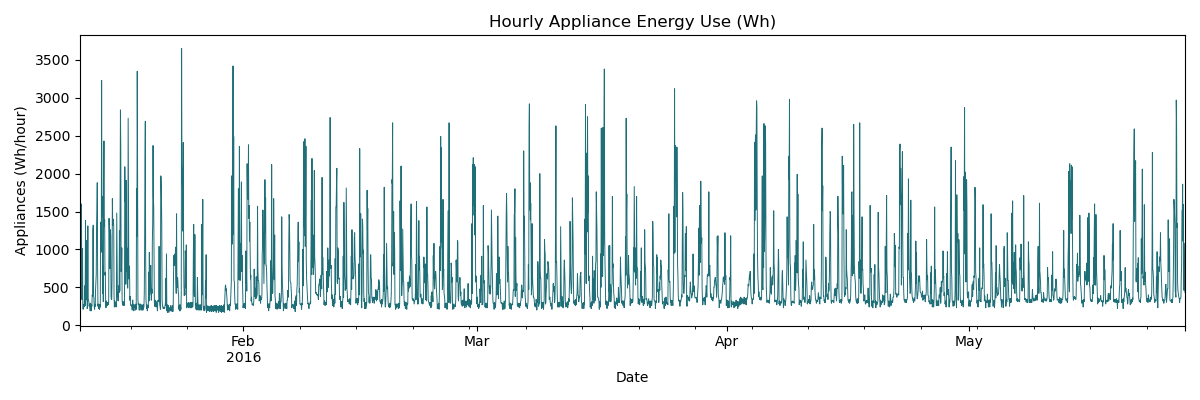

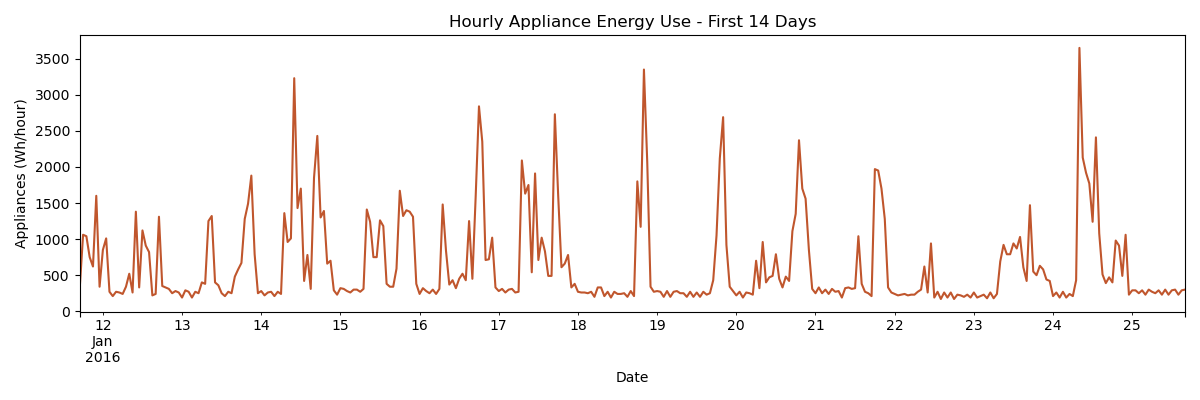

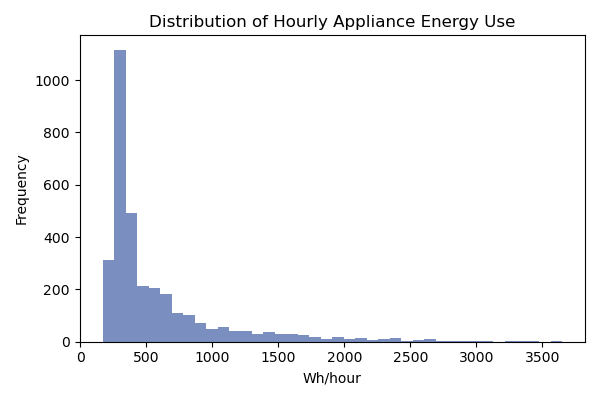

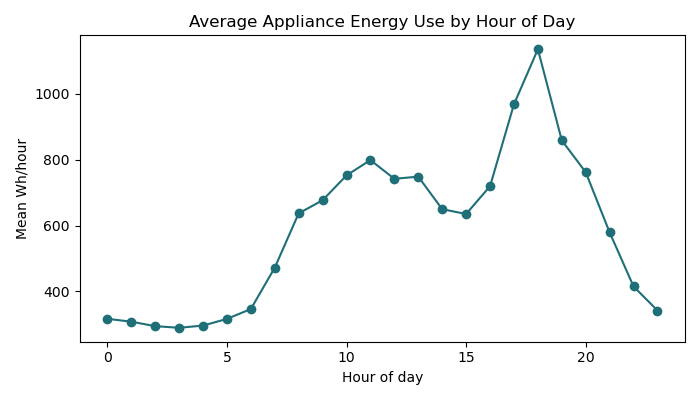

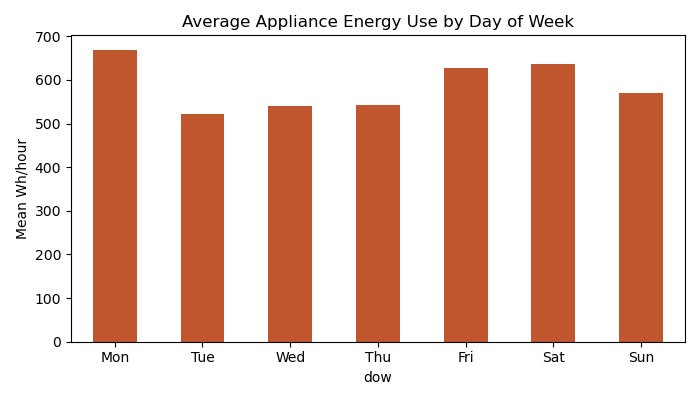

In [77]:
### Initial plots and EDA
plot_series(hourly)
display(Image(f"{FIGDIR}/01_hourly_series.png"))
display(Image(f"{FIGDIR}/02_hourly_series_2weeks.png"))
display(Image(f"{FIGDIR}/03_hist.png"))
display(Image(f"{FIGDIR}/04_hourly_profile.png"))
display(Image(f"{FIGDIR}/05_weekly_profile.png"))

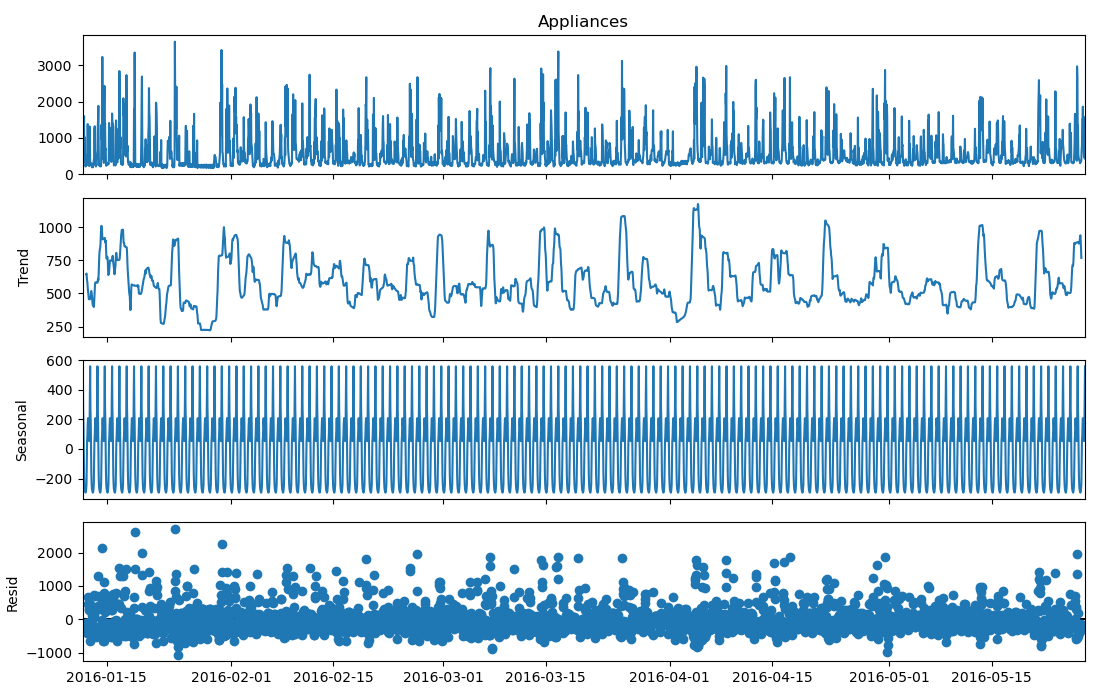

In [49]:
result_daily, result_weekly = decomposition(hourly)
display(Image(f"{FIGDIR}/06_decomposition_daily.png"))

*Figure: Additive decomposition with a 24-hour period: a clear, stable daily seasonal component and a noisy but roughly flat trend.*

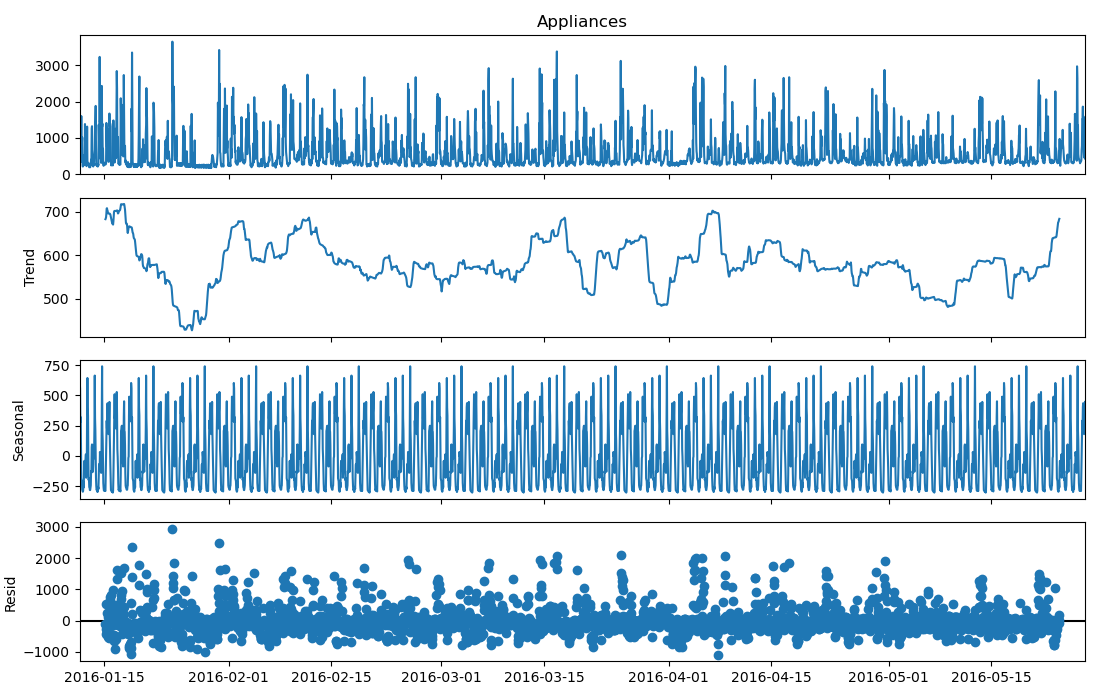

In [50]:
display(Image(f"{FIGDIR}/07_decomposition_weekly.png"))

*Figure: Additive decomposition with a 168-hour (weekly) period, showing a secondary weekly rhythm layered on top of the daily one.*

### Stationarity testing


In [51]:
stats_level = stationarity_tests(hourly["Appliances"])
diff1 = hourly["Appliances"].diff().dropna()
diff24 = hourly["Appliances"].diff(24).dropna()
stats_diff1 = stationarity_tests(diff1)
stats_diff24 = stationarity_tests(diff24)

print("Level series      -> ADF p =", round(stats_level["ADF_pvalue"], 4),
      "| KPSS p =", stats_level["KPSS_pvalue"],
      "| ADF says stationary:", stats_level["ADF_stationary_at_5pct"],
      "| KPSS says stationary:", stats_level["KPSS_stationary_at_5pct"])
print("1st difference     -> ADF p =", round(stats_diff1["ADF_pvalue"], 4),
      "| KPSS p =", stats_diff1["KPSS_pvalue"])
print("24h seasonal diff  -> ADF p =", round(stats_diff24["ADF_pvalue"], 4),
      "| KPSS p =", stats_diff24["KPSS_pvalue"])


Level series      -> ADF p = 0.0 | KPSS p = 0.1 | ADF says stationary: True | KPSS says stationary: True
1st difference     -> ADF p = 0.0 | KPSS p = 0.1
24h seasonal diff  -> ADF p = 0.0 | KPSS p = 0.1


In [52]:
acf_pacf(hourly["Appliances"], lags=72, tag="level series")
acf_pacf(diff1, lags=72, tag="first differenced")
acf_pacf(diff24, lags=72, tag="24h seasonally differenced")


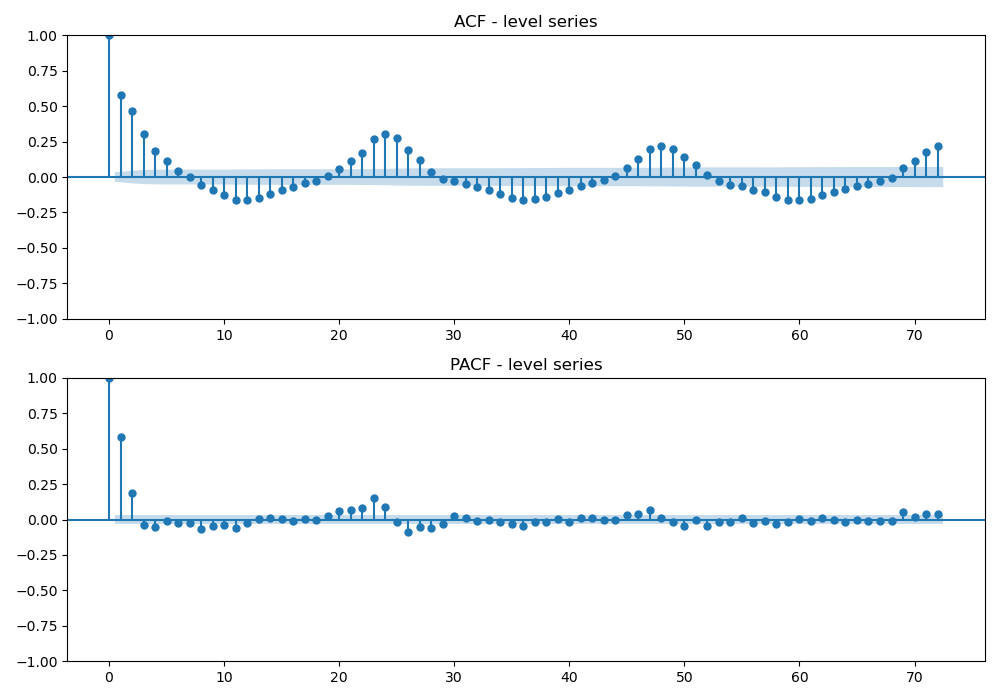

In [53]:
display(Image(f"{FIGDIR}/08_acf_pacf_level_series.png"))

*Figure: ACF/PACF of the level series.*


## Part 2: Forecasting Problem Definition

In [79]:
target_col = "Appliances"
horizon = 24
test_days = 14
test_hours = test_days * 24

train, test = hourly.iloc[:-test_hours], hourly.iloc[-test_hours:]

print(f"Target: {target_col}")
print(f"Horizon: {horizon} hours")
print(f"Test period: {test_days} days ({test_hours} hours)")
print(f"Train: {len(train)} rows | Test: {len(test)} rows")
print(f"Train range: {train.index.min()} to {train.index.max()}")
print(f"Test range:  {test.index.min()} to {test.index.max()}")

Target: Appliances
Horizon: 24 hours
Test period: 14 days (336 hours)
Train: 2954 rows | Test: 336 rows
Train range: 2016-01-11 17:00:00 to 2016-05-13 18:00:00
Test range:  2016-05-13 19:00:00 to 2016-05-27 18:00:00


## Part 3: Benchmark Models

In [54]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100)

def all_metrics(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred),
            "MAPE": mape(y_true, y_pred), "sMAPE": smape(y_true, y_pred)}


def train_test_split(hourly, test_days=14):
    """Hold out the last `test_days` (24 * test_days hours) as the test set."""
    test_hours = 24 * test_days
    train = hourly.iloc[:-test_hours]
    test = hourly.iloc[-test_hours:]
    return train, test


def mean_forecast(train, horizon):
    return np.full(horizon, train["Appliances"].mean())

def naive_forecast(train, horizon):
    return np.full(horizon, train["Appliances"].iloc[-1])

def seasonal_naive_forecast(train, horizon, season):
    last_season = train["Appliances"].iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    return np.tile(last_season, reps)[:horizon]

def drift_forecast(train, horizon):
    y = train["Appliances"].values
    n = len(y)
    slope = (y[-1] - y[0]) / (n - 1)
    return y[-1] + slope * np.arange(1, horizon + 1)


def rolling_origin_evaluation(hourly, test_days=14, horizon=24):
    """Rolling-origin (walk-forward) evaluation over the test block."""
    test_hours = 24 * test_days
    origins = list(range(len(hourly) - test_hours - horizon, len(hourly) - horizon, 24))

    results = {name: {"RMSE": [], "MAE": [], "MAPE": [], "sMAPE": []}
               for name in ["Mean", "Naive", "Seasonal_Naive_24h", "Seasonal_Naive_168h", "Drift"]}

    example_store = None
    for origin in origins:
        train = hourly.iloc[:origin]
        test = hourly.iloc[origin:origin + horizon]
        y_true = test["Appliances"].values
        preds = {
            "Mean": mean_forecast(train, horizon),
            "Naive": naive_forecast(train, horizon),
            "Seasonal_Naive_24h": seasonal_naive_forecast(train, horizon, 24),
            "Seasonal_Naive_168h": seasonal_naive_forecast(train, horizon, 168),
            "Drift": drift_forecast(train, horizon),
        }
        for name, y_pred in preds.items():
            m = all_metrics(y_true, y_pred)
            for k in results[name]:
                results[name][k].append(m[k])
        if origin == origins[-1]:
            example_store = (test.index, y_true, preds)

    summary = {name: {k: float(np.mean(v)) for k, v in metrics.items()}
               for name, metrics in results.items()}
    return summary, example_store


def plot_example(example_store, best_name=None):
    idx, y_true, preds = example_store
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(idx, y_true, label="Actual", color="black", lw=2)
    colors = {"Mean": "#999999", "Naive": "#c0562d", "Seasonal_Naive_24h": "#1f6f78",
              "Seasonal_Naive_168h": "#7a8fbf", "Drift": "#e0a800"}
    for name, y_pred in preds.items():
        ax.plot(idx, y_pred, label=name.replace("_", " "), color=colors.get(name), lw=1.3, ls="--")
    ax.set_title("Benchmark 24-hour Forecasts vs Actual (final test-window origin)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Appliances (Wh/hour)")
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/09_benchmark_forecasts.png")
    plt.close(fig)


train, test = train_test_split(hourly, test_days=14)
print("Train hours:", len(train), " Test hours:", len(test))

bench_summary, example_store = rolling_origin_evaluation(hourly, test_days=14, horizon=24)
plot_example(example_store)

with open(f"{RESDIR}/part2_3_benchmarks.json", "w") as f:
    json.dump({
        "target_variable": "Appliances (Wh consumed per hour, hourly-resampled)",
        "forecast_horizon_hours": 24, "train_rows": len(train), "test_rows": len(test),
        "test_period_days": 14, "evaluation_metrics": ["RMSE", "MAE", "MAPE", "sMAPE"],
        "benchmark_results_mean_over_origins": bench_summary,
        "best_benchmark": min(bench_summary, key=lambda k: bench_summary[k]["RMSE"]),
    }, f, indent=2)

pd.DataFrame(bench_summary).T.round(2)


Train hours: 2954  Test hours: 336


,RMSE,MAE,MAPE,sMAPE
Mean,412.49,312.11,54.22,47.06
Naive,588.89,507.80,107.35,64.79
Seasonal_Naive_24h,471.50,303.72,43.33,37.38
Seasonal_Naive_168h,419.75,266.79,37.59,32.63
Drift,590.02,509.17,107.72,64.89


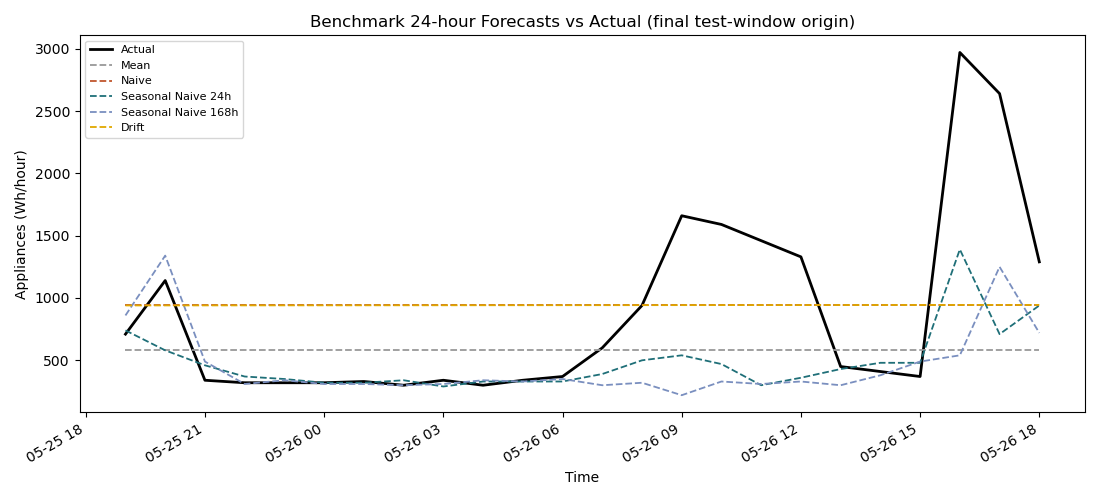

In [55]:
display(Image(f"{FIGDIR}/09_benchmark_forecasts.png"))

*Figure: All five benchmark forecasts against the actual load for the final rolling-origin
test window.*


## Part 4: SARIMA / SARIMAX Modelling

In [56]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as sstats
import itertools

def grid_search_aic(train_subset, p_range=range(0, 7), d_range=range(0, 3), q_range=range(0, 7)):
    """Loop over p in [0,6], d in [0,2], q in [0,6] as specified in the brief,
    fitting a non-seasonal ARIMA on a recent subsample of the training data
    (for tractable runtime) and selecting the combination with the lowest AIC."""
    combos = list(itertools.product(p_range, d_range, q_range))
    records = []
    for (p, d, q) in combos:
        try:
            mod = SARIMAX(train_subset, order=(p, d, q),
                           enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False, maxiter=50)
            records.append({"p": p, "d": d, "q": q, "aic": float(res.aic), "bic": float(res.bic)})
        except Exception:
            continue
    return pd.DataFrame(records).sort_values("aic").reset_index(drop=True)


def fit_sarimax(train, order, seasonal_order, exog_train=None, maxiter=200):
    mod = SARIMAX(train, order=order, seasonal_order=seasonal_order, exog=exog_train,
                   enforce_stationarity=False, enforce_invertibility=False)
    return mod.fit(disp=False, maxiter=maxiter)


def residual_diagnostics(res, tag):
    resid = res.resid.dropna()
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes[0, 0].plot(resid, color="#1f6f78", lw=0.6)
    axes[0, 0].set_title("Residuals over time")
    axes[0, 1].hist(resid, bins=30, color="#7a8fbf")
    axes[0, 1].set_title("Residual distribution")
    from statsmodels.graphics.tsaplots import plot_acf as _plot_acf
    _plot_acf(resid, lags=48, ax=axes[1, 0])
    axes[1, 0].set_title("Residual ACF")
    sstats.probplot(resid, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("Q-Q plot")
    fig.suptitle(f"Residual diagnostics - {tag}")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/{tag}_residual_diagnostics.png")
    plt.close(fig)
    lb = acorr_ljungbox(resid, lags=[24], return_df=True)
    return {"ljung_box_stat": float(lb["lb_stat"].iloc[0]), "ljung_box_pvalue": float(lb["lb_pvalue"].iloc[0]),
            "residual_mean": float(resid.mean()), "residual_std": float(resid.std())}


def forecast_and_eval(res, test, horizon, exog_test=None, tag=""):
    fc = res.get_forecast(steps=horizon, exog=exog_test)
    mean_fc, ci = fc.predicted_mean, fc.conf_int(alpha=0.05)
    y_true, y_pred = test["Appliances"].values[:horizon], mean_fc.values[:horizon]
    metrics = {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred)}
    fig, ax = plt.subplots(figsize=(11, 5))
    idx = test.index[:horizon]
    ax.plot(idx, y_true, label="Actual", color="black", lw=2)
    ax.plot(idx, y_pred, label="SARIMAX forecast", color="#c0562d", lw=1.5)
    ax.fill_between(idx, ci.iloc[:horizon, 0], ci.iloc[:horizon, 1], color="#c0562d", alpha=0.2, label="95% CI")
    ax.set_title(f"SARIMAX 24h Forecast with 95% Confidence Interval ({tag})")
    ax.set_ylabel("Appliances (Wh/hour)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/10_sarimax_forecast_{tag}.png")
    plt.close(fig)
    return metrics, y_pred, ci


def make_exog(df):
    hour = df.index.hour
    return pd.DataFrame({"T_out": df["T_out"].values, "RH_out": df["RH_out"].values,
                          "hour_sin": np.sin(2 * np.pi * hour / 24), "hour_cos": np.cos(2 * np.pi * hour / 24)},
                         index=df.index)


# Grid search on a recent 45-day training subsample for tractable runtime
subset = train["Appliances"].iloc[-24 * 45:]
grid = grid_search_aic(subset)
grid.to_csv(f"{RESDIR}/part4_grid_search.csv", index=False)
print("Top 10 (p,d,q) combinations by AIC:")
grid.head(10)


Top 10 (p,d,q) combinations by AIC:


,p,d,q,aic,bic
0,1,1,6,15644.272069,15684.090320
1,2,1,6,15646.615688,15691.411220
2,3,1,6,15648.656269,15698.429082
3,5,1,6,15649.023404,15708.750780
4,4,1,6,15650.376254,15705.126349
5,0,1,6,15650.461279,15685.302249
6,6,1,6,15651.573415,15716.278072
7,6,1,1,15655.217094,15695.042804
8,6,1,2,15656.971988,15701.775911
9,2,1,5,15658.760932,15698.586642


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top 10 (p,d,q) combinations by AIC:


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,aic,bic
0,1,1,6,15644.272069,15684.090320
1,2,1,6,15646.615688,15691.411220
2,3,1,6,15648.656203,15698.429016
3,5,1,6,15648.901634,15708.629010
4,4,1,6,15650.381987,15705.132082
5,0,1,6,15650.461279,15685.302249
6,6,1,6,15651.573474,15716.278131
7,6,1,1,15655.217104,15695.042814
8,6,1,2,15656.972405,15701.776329
9,2,1,5,15658.750541,15698.576251


In [57]:
best = grid.iloc[0]
order = (int(best.p), int(best.d), int(best.q))
seasonal_order = (1, 1, 1, 24)  # daily seasonality, justified by the Part 1 ACF/decomposition evidence

# 1) Non-seasonal best-AIC ARIMA
res_arima = fit_sarimax(train["Appliances"], order, (0, 0, 0, 0))
diag_arima = residual_diagnostics(res_arima, "arima_bestaic")
metrics_arima, _, _ = forecast_and_eval(res_arima, test, 24, tag="arima_bestaic")
arima_res = {"order": order, "metrics_24h": metrics_arima, "residual_diagnostics": diag_arima,
             "aic": float(res_arima.aic), "bic": float(res_arima.bic)}
with open(f"{RESDIR}/part4_arima_bestaic.json", "w") as f:
    json.dump(arima_res, f, indent=2)
print("ARIMA best-AIC:", arima_res["metrics_24h"], " AIC:", round(arima_res["aic"], 1))


ARIMA best-AIC: {'RMSE': 339.1410419017052, 'MAE': 275.96797442622164}  AIC: 43583.4


In [58]:
# 2) Seasonal SARIMA (no exogenous variables)
res_sarima = fit_sarimax(train["Appliances"], order, seasonal_order)
diag_sarima = residual_diagnostics(res_sarima, "sarima_seasonal")
metrics_sarima, _, _ = forecast_and_eval(res_sarima, test, 24, tag="sarima_seasonal")
sarima_res = {"order": order, "seasonal_order": seasonal_order, "metrics_24h": metrics_sarima,
              "residual_diagnostics": diag_sarima, "aic": float(res_sarima.aic), "bic": float(res_sarima.bic)}
with open(f"{RESDIR}/part4_sarima_seasonal.json", "w") as f:
    json.dump(sarima_res, f, indent=2)
print("SARIMA seasonal:", sarima_res["metrics_24h"], " AIC:", round(sarima_res["aic"], 1))


SARIMA seasonal: {'RMSE': 137.48380180620933, 'MAE': 104.62957900306473}  AIC: 42573.2


In [59]:
# 3) Full SARIMAX (seasonal + exogenous weather/hour regressors)
exog_train, exog_test = make_exog(train), make_exog(test)
res_sarimax = fit_sarimax(train["Appliances"], order, seasonal_order, exog_train, maxiter=200)
diag_sarimax = residual_diagnostics(res_sarimax, "sarimax_full")
metrics_sarimax, y_pred_sarimax, ci_sarimax = forecast_and_eval(
    res_sarimax, test, 24, exog_test=exog_test.iloc[:24], tag="sarimax_full")
sarimax_res = {"order": order, "seasonal_order": seasonal_order, "exog": list(exog_train.columns),
                "metrics_24h": metrics_sarimax, "residual_diagnostics": diag_sarimax,
                "aic": float(res_sarimax.aic), "bic": float(res_sarimax.bic)}
with open(f"{RESDIR}/part4_sarimax_full.json", "w") as f:
    json.dump(sarimax_res, f, indent=2)
print("SARIMAX seasonal+exog:", sarimax_res["metrics_24h"], " AIC:", round(sarimax_res["aic"], 1))

for label, res_d in [("ARIMA (best AIC, no seasonality)", arima_res),
                      ("SARIMA (seasonal, no exog)", sarima_res),
                      ("SARIMAX (seasonal + weather/hour exog)", sarimax_res)]:
    print(f"{label:45s} RMSE={res_d['metrics_24h']['RMSE']:.1f}  MAE={res_d['metrics_24h']['MAE']:.1f}  AIC={res_d['aic']:.1f}")


SARIMAX seasonal+exog: {'RMSE': 227.7345576078088, 'MAE': 186.77725863734986}  AIC: 42939.1
ARIMA (best AIC, no seasonality)              RMSE=339.1  MAE=276.0  AIC=43583.4
SARIMA (seasonal, no exog)                    RMSE=137.5  MAE=104.6  AIC=42573.2
SARIMAX (seasonal + weather/hour exog)        RMSE=227.7  MAE=186.8  AIC=42939.1


Selected order: (1, 1, 6)  Seasonal order: (1, 1, 1, 24)


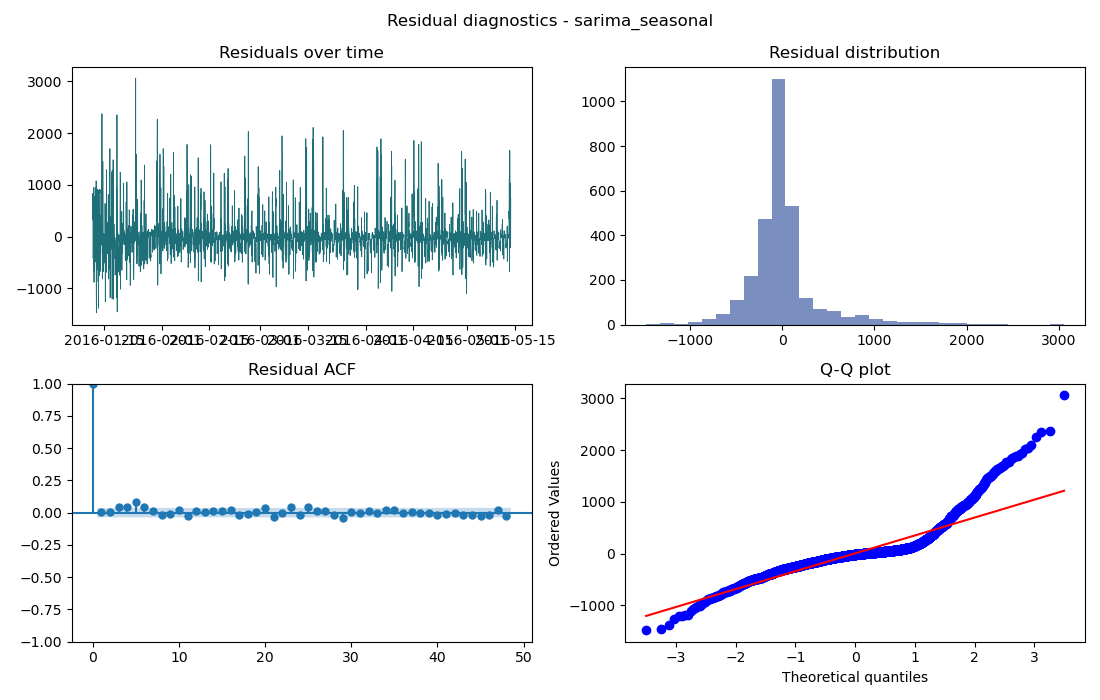

In [60]:
print("Selected order:", order, " Seasonal order:", seasonal_order)
display(Image(f"{FIGDIR}/sarima_seasonal_residual_diagnostics.png"))


*Figure: Residual diagnostics for the seasonal SARIMA model*


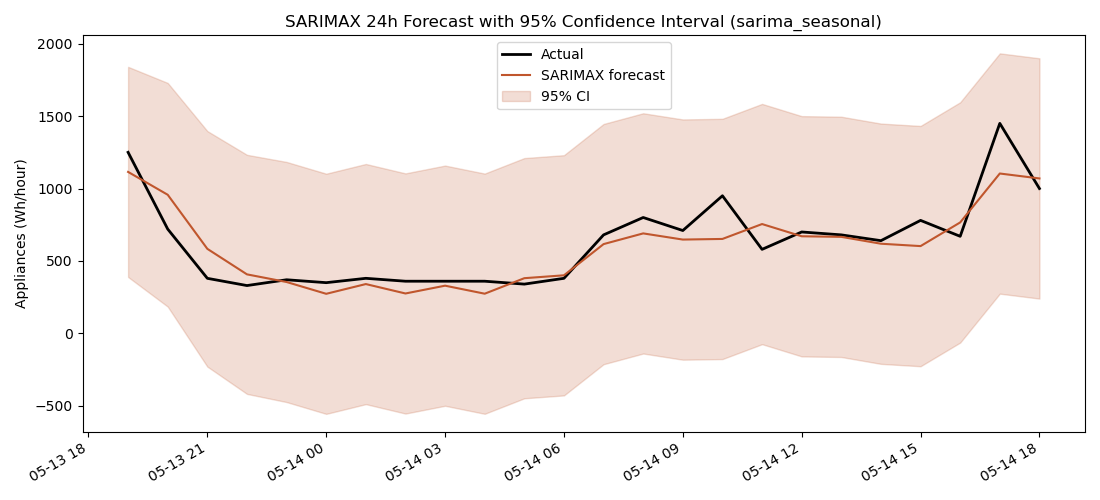

In [61]:
display(Image(f"{FIGDIR}/10_sarimax_forecast_sarima_seasonal.png"))

*Figure: SARIMA(1,1,6)(1,1,1)[24] 24h-ahead forecast with 95% confidence interval, closely tracking the actual daily shape.*

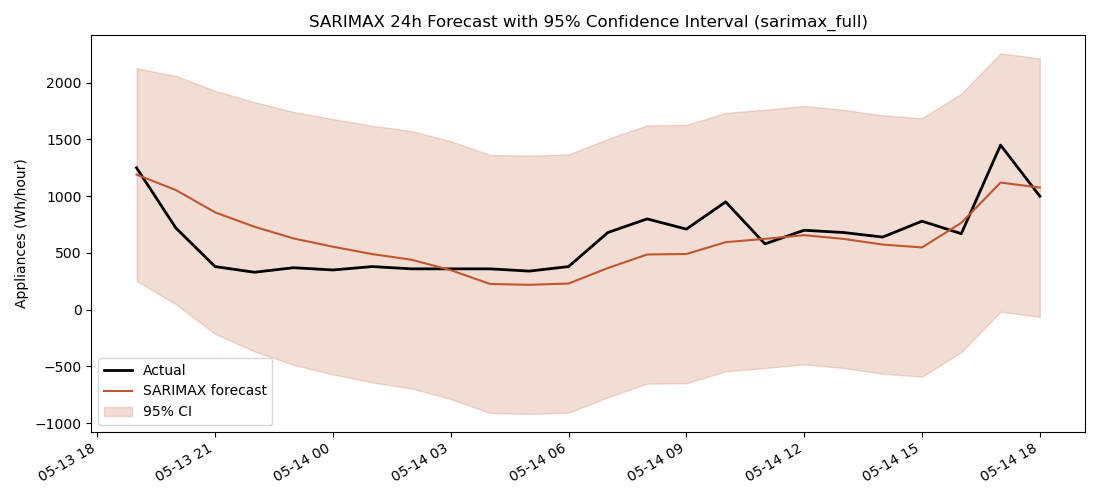

In [62]:
display(Image(f"{FIGDIR}/10_sarimax_forecast_sarimax_full.png"))

*Figure: Full SARIMAX (seasonal + exogenous weather/hour) forecast — visually similar
shape but a worse fit than the seasonal-only model on this window.*

## Part 5: Feature Engineering & Part 6: Feature-based ML Model (XGBoost)


In [63]:
from xgboost import XGBRegressor

def build_features(hourly):
    """Leakage-safe feature set: all target lags >=24h, calendar features
    (always safe), rolling stats on lagged windows, weather covariates lagged
    24h -- so a 24h-ahead forecast never needs a value that would not yet be
    known at the forecast origin."""
    df = hourly.copy()
    df["hour"] = df.index.hour
    df["dow"] = df.index.dayofweek
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

    for lag in [24, 25, 48, 72, 168]:
        df[f"appl_lag{lag}"] = df["Appliances"].shift(lag)

    lag24 = df["Appliances"].shift(24)
    df["appl_roll24_mean"] = lag24.rolling(24).mean()
    df["appl_roll24_std"] = lag24.rolling(24).std()
    df["appl_roll168_mean"] = lag24.rolling(168).mean()

    weather_cols = ["T_out", "RH_out", "Windspeed", "Visibility", "Tdewpoint",
                     "Press_mm_hg", "T1", "RH_1", "T3", "RH_3"]
    for col in weather_cols:
        df[f"{col}_lag24"] = df[col].shift(24)

    df = df.dropna()
    feature_cols = [c for c in df.columns if c.endswith(("_sin", "_cos")) or
                     c.startswith("appl_lag") or c.startswith("appl_roll") or
                     c.endswith("_lag24") or c == "is_weekend"]
    return df, feature_cols


def rolling_origin_xgb(df, feature_cols, test_days=14, horizon=24):
    test_hours = 24 * test_days
    origins = list(range(len(df) - test_hours, len(df) - horizon + 1, 24))
    all_true, all_pred, importances = [], [], []
    last_test_index = last_y_test = last_y_pred = None

    for origin in origins:
        train_df, test_df = df.iloc[:origin], df.iloc[origin:origin + horizon]
        if len(test_df) < horizon:
            continue
        X_train, y_train = train_df[feature_cols], train_df["Appliances"]
        X_test, y_test = test_df[feature_cols], test_df["Appliances"]
        model = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8, random_state=42,
                              reg_lambda=1.0, n_jobs=4)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        all_true.extend(y_test.values.tolist())
        all_pred.extend(y_pred.tolist())
        importances.append(model.feature_importances_)
        last_test_index, last_y_test, last_y_pred = test_df.index, y_test.values, y_pred

    overall = all_metrics(all_true, all_pred)
    imp_series = pd.Series(np.mean(importances, axis=0), index=feature_cols).sort_values(ascending=False)
    return overall, None, imp_series, (last_test_index, last_y_test, last_y_pred), model


def ablation_study(df, feature_cols, test_days=14, horizon=24):
    groups = {
        "lags_only": [c for c in feature_cols if c.startswith("appl_lag")],
        "lags_plus_calendar": [c for c in feature_cols if c.startswith("appl_lag") or
                                c.endswith(("_sin", "_cos")) or c == "is_weekend"],
        "lags_plus_rolling": [c for c in feature_cols if c.startswith("appl_lag") or
                               c.startswith("appl_roll")],
        "full_feature_set": feature_cols,
    }
    return {name: rolling_origin_xgb(df, cols, test_days, horizon)[0] for name, cols in groups.items()}


def plot_importance(imp_series):
    fig, ax = plt.subplots(figsize=(8, 6))
    imp_series.head(15).sort_values().plot(kind="barh", ax=ax, color="#1f6f78")
    ax.set_title("XGBoost Feature Importance (top 15, mean over rolling origins)")
    ax.set_xlabel("Importance")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/11_xgb_feature_importance.png")
    plt.close(fig)


def plot_forecast(example, tag="xgb"):
    idx, y_true, y_pred = example
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(idx, y_true, label="Actual", color="black", lw=2)
    ax.plot(idx, y_pred, label="XGBoost forecast", color="#1f6f78", lw=1.5, ls="--")
    ax.set_title("XGBoost 24h Forecast vs Actual (final test-window origin)")
    ax.set_ylabel("Appliances (Wh/hour)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/12_xgb_forecast.png")
    plt.close(fig)


df_feat, feature_cols = build_features(hourly)
print("Engineered features:", len(feature_cols))
print(feature_cols)
df_feat[feature_cols + ["Appliances"]].head()


Engineered features: 23
['is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'appl_lag24', 'appl_lag25', 'appl_lag48', 'appl_lag72', 'appl_lag168', 'appl_roll24_mean', 'appl_roll24_std', 'appl_roll168_mean', 'T_out_lag24', 'RH_out_lag24', 'Windspeed_lag24', 'Visibility_lag24', 'Tdewpoint_lag24', 'Press_mm_hg_lag24', 'T1_lag24', 'RH_1_lag24', 'T3_lag24', 'RH_3_lag24']


,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,appl_lag24,appl_lag25,appl_lag48,appl_lag72,appl_lag168,appl_roll24_mean,appl_roll24_std,appl_roll168_mean,T_out_lag24,RH_out_lag24,Windspeed_lag24,Visibility_lag24,Tdewpoint_lag24,Press_mm_hg_lag24,T1_lag24,RH_1_lag24,T3_lag24,RH_3_lag24,Appliances
date,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-19 16:00:00,0,-0.866025,-5.000000e-01,0.781831,0.62349,280.0,200.0,490.0,450.0,240.0,475.833333,567.365511,683.392857,-0.791667,75.000000,2.000000,35.416667,-4.816667,756.716667,19.290000,41.326667,19.575000,40.628194,250
2016-01-19 17:00:00,0,-0.965926,-2.588190e-01,0.781831,0.62349,210.0,280.0,2730.0,1590.0,1310.0,370.833333,304.215551,682.678571,-1.533333,84.083333,2.416667,26.916667,-3.958333,756.600000,19.172222,41.175556,19.500000,40.693889,430
2016-01-19 18:00:00,0,-1.000000,-1.836970e-16,0.781831,0.62349,1800.0,210.0,1610.0,2840.0,350.0,378.750000,338.414622,687.083333,-2.208333,85.333333,3.000000,24.000000,-4.358333,756.600000,19.100000,41.075556,19.357222,40.324444,1050
2016-01-19 19:00:00,0,-0.965926,2.588190e-01,0.781831,0.62349,1170.0,1800.0,610.0,2350.0,330.0,402.083333,372.628492,687.857143,-2.500000,80.916667,3.000000,25.250000,-5.333333,756.725000,19.574444,42.057778,19.488889,40.265556,2120
2016-01-19 20:00:00,0,-0.866025,5.000000e-01,0.781831,0.62349,3350.0,1170.0,660.0,710.0,310.0,514.166667,707.591854,703.333333,-2.708333,80.083333,2.583333,25.750000,-5.675000,756.858333,20.258611,41.407083,20.196667,43.094444,2690


In [64]:
overall, per_origin, imp_series, example, model = rolling_origin_xgb(df_feat, feature_cols)
plot_importance(imp_series)
plot_forecast(example)
print("Rolling-origin XGBoost metrics (24h horizon, 14 origins):")
print(json.dumps(overall, indent=2))


Rolling-origin XGBoost metrics (24h horizon, 14 origins):
{
  "RMSE": 401.84975091797884,
  "MAE": 243.36205382574173,
  "MAPE": 39.06781140712269,
  "sMAPE": 33.0295772671693
}


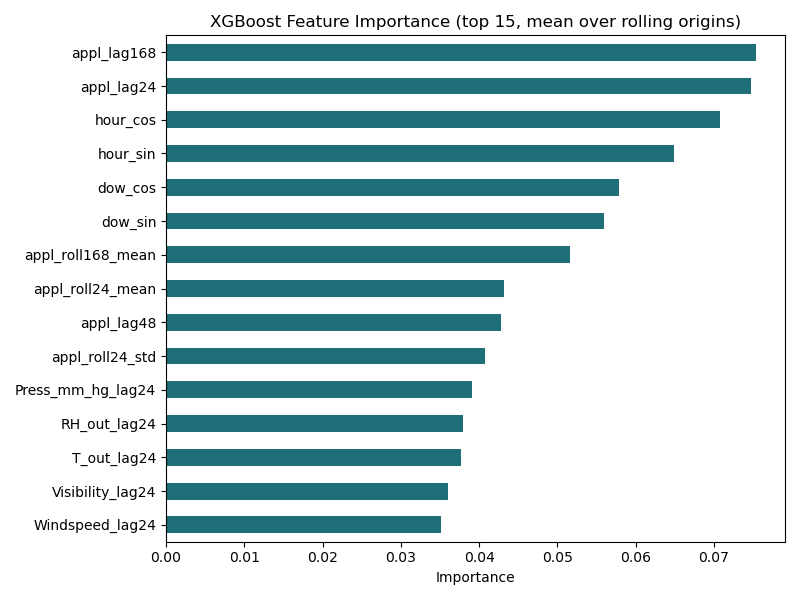

In [65]:
display(Image(f"{FIGDIR}/11_xgb_feature_importance.png"))

*Figure: Mean XGBoost feature importance across the 14 rolling origins. The weekly lag (168h), the 24h lag, and the hour-of-day cyclic features dominate — consistent with the daily/weekly seasonality identified in Part 1.*

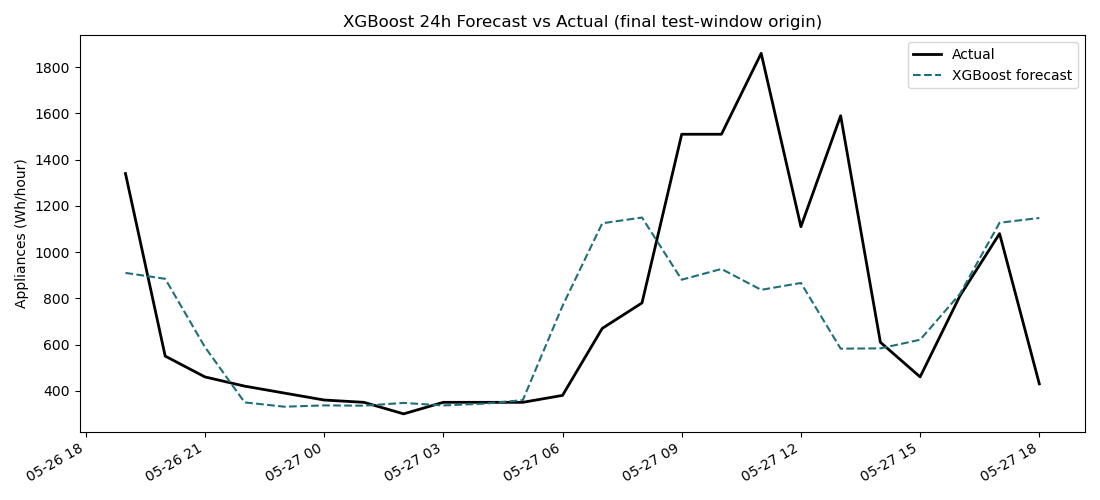

In [66]:
display(Image(f"{FIGDIR}/12_xgb_forecast.png"))

*Figure: XGBoost 24h forecast vs actual for the final test window.*

### Ablation: which feature groups help?

In [67]:
ablation = ablation_study(df_feat, feature_cols)

with open(f"{RESDIR}/part5_6_xgboost.json", "w") as f:
    json.dump({
        "n_features": len(feature_cols), "feature_columns": feature_cols,
        "rolling_origin_overall_metrics": overall,
        "feature_group_ablation_rmse": {k: v["RMSE"] for k, v in ablation.items()},
        "feature_group_ablation_full": ablation,
        "top_10_features_by_importance": imp_series.head(10).to_dict(),
    }, f, indent=2, default=float)

pd.DataFrame(ablation).T[["RMSE", "MAE", "MAPE", "sMAPE"]].round(2)


,RMSE,MAE,MAPE,sMAPE
lags_only,407.49,236.97,37.97,32.08
lags_plus_calendar,386.24,219.70,33.22,28.99
lags_plus_rolling,411.68,242.34,38.86,32.91
full_feature_set,401.85,243.36,39.07,33.03


## Part 7: Time-Series Foundation Model

In [68]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def try_load_chronos():
    """Genuine attempt to load Chronos; returns (pipeline_or_None, error_str_or_None)."""
    try:
        import torch
        from chronos import ChronosPipeline
        pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small", device_map="cpu")
        return pipeline, None
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"


def foundation_or_fallback_forecast(train_series, horizon, pipeline=None):
    if pipeline is not None:
        import torch
        context = torch.tensor(train_series.values[-24 * 14:], dtype=torch.float32)
        forecast = pipeline.predict(context.unsqueeze(0), horizon)
        return np.median(forecast[0].numpy(), axis=0)
    else:
        series = train_series.iloc[-24 * 30:]
        model = ExponentialSmoothing(series, trend=None, seasonal="add", seasonal_periods=24,
                                      initialization_method="estimated").fit(optimized=True)
        return model.forecast(horizon).values


def rolling_origin_fm(hourly, pipeline, test_days=14, horizon=24):
    test_hours = 24 * test_days
    origins = list(range(len(hourly) - test_hours, len(hourly) - horizon + 1, 24))
    results = {"RMSE": [], "MAE": [], "MAPE": [], "sMAPE": []}
    example = None
    for origin in origins:
        train_s = hourly["Appliances"].iloc[:origin]
        test_s = hourly["Appliances"].iloc[origin:origin + horizon]
        y_pred = foundation_or_fallback_forecast(train_s, horizon, pipeline)
        y_true = test_s.values
        m = all_metrics(y_true, y_pred)
        for k in results:
            results[k].append(m[k])
        if origin == origins[-1]:
            example = (test_s.index, y_true, y_pred)
    return {k: float(np.mean(v)) for k, v in results.items()}, example


def plot_fm_example(example, model_label):
    idx, y_true, y_pred = example
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(idx, y_true, label="Actual", color="black", lw=2)
    ax.plot(idx, y_pred, label=f"{model_label} forecast", color="#7a8fbf", lw=1.5, ls="--")
    ax.set_title(f"{model_label} 24h Forecast vs Actual (final test-window origin)")
    ax.set_ylabel("Appliances (Wh/hour)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/13_foundation_model_forecast.png")
    plt.close(fig)


pipeline, error = try_load_chronos()
print("Chronos available:", pipeline is not None)
print("Load error:", error)

fm_summary, fm_example = rolling_origin_fm(hourly, pipeline, test_days=14, horizon=24)
model_label = "Chronos-T5 (zero-shot)" if pipeline is not None else \
    "Holt-Winters Exponential Smoothing (documented substitute for Chronos)"
plot_fm_example(fm_example, model_label)

with open(f"{RESDIR}/part7_foundation_model.json", "w") as f:
    json.dump({
        "chronos_available": pipeline is not None, "chronos_load_error": error,
        "model_used": model_label, "rolling_origin_metrics": fm_summary,
        "note": ("Chronos requires downloading pretrained weights from huggingface.co; if that "
                 "host is unreachable, or the local PyTorch/CUDA install is broken, this falls "
                 "back to Holt-Winters exponential smoothing, clearly labelled as a substitute."),
    }, f, indent=2)

print("\nRolling-origin metrics:")
print(json.dumps(fm_summary, indent=2))


Chronos available: False
Load error: ModuleNotFoundError: No module named 'torch'

Rolling-origin metrics:
{
  "RMSE": 434.5204358902318,
  "MAE": 338.24185693474334,
  "MAPE": 61.6768754198474,
  "sMAPE": 54.123103031162394
}



Rolling-origin metrics:
{
  "RMSE": 434.5321713362575,
  "MAE": 338.1986701584694,
  "MAPE": 61.74694139964189,
  "sMAPE": 54.432126093189574
}


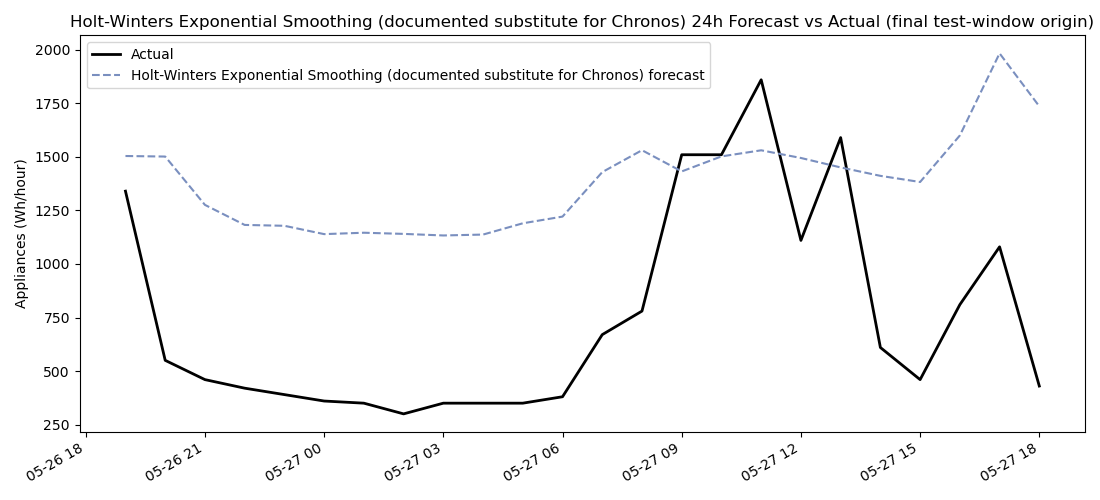

In [69]:
display(Image(f"{FIGDIR}/13_foundation_model_forecast.png"))

*Figure: Holt-Winters (Chronos substitute) 24h forecast vs actual for the final test
window. The model captures the broad daily shape but smooths over the sharper real-world
peaks.*


## Part 8: Full Model Comparison

In [70]:
def run_comparison():
    with open(f"{RESDIR}/part2_3_benchmarks.json") as f:
        p23 = json.load(f)
    with open(f"{RESDIR}/part4_arima_bestaic.json") as f:
        p4a = json.load(f)
    with open(f"{RESDIR}/part4_sarima_seasonal.json") as f:
        p4s = json.load(f)
    with open(f"{RESDIR}/part4_sarimax_full.json") as f:
        p4x = json.load(f)
    with open(f"{RESDIR}/part5_6_xgboost.json") as f:
        p6 = json.load(f)
    with open(f"{RESDIR}/part7_foundation_model.json") as f:
        p7 = json.load(f)

    rows = []
    for name, m in p23["benchmark_results_mean_over_origins"].items():
        rows.append({"Model": name.replace("_", " "), "RMSE": m["RMSE"], "MAE": m["MAE"],
                      "MAPE": m["MAPE"], "sMAPE": m["sMAPE"], "Family": "Benchmark"})

    rows.append({"Model": "ARIMA(1,1,6) best-AIC, no seasonality", "RMSE": p4a["metrics_24h"]["RMSE"],
                 "MAE": p4a["metrics_24h"]["MAE"], "MAPE": None, "sMAPE": None, "Family": "SARIMA/X (single origin)"})
    rows.append({"Model": "SARIMA(1,1,6)(1,1,1)[24]", "RMSE": p4s["metrics_24h"]["RMSE"],
                 "MAE": p4s["metrics_24h"]["MAE"], "MAPE": None, "sMAPE": None, "Family": "SARIMA/X (single origin)"})
    rows.append({"Model": "SARIMAX + weather/hour exog", "RMSE": p4x["metrics_24h"]["RMSE"],
                 "MAE": p4x["metrics_24h"]["MAE"], "MAPE": None, "sMAPE": None, "Family": "SARIMA/X (single origin)"})

    m = p6["rolling_origin_overall_metrics"]
    rows.append({"Model": "XGBoost (full feature set)", "RMSE": m["RMSE"], "MAE": m["MAE"],
                 "MAPE": m["MAPE"], "sMAPE": m["sMAPE"], "Family": "ML"})

    m7 = p7["rolling_origin_metrics"]
    rows.append({"Model": p7["model_used"], "RMSE": m7["RMSE"], "MAE": m7["MAE"],
                 "MAPE": m7["MAPE"], "sMAPE": m7["sMAPE"], "Family": "Foundation model"})

    table = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    table.to_csv(f"{RESDIR}/part8_comparison_table.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = {"Benchmark": "#999999", "SARIMA/X (single origin)": "#c0562d",
              "ML": "#1f6f78", "Foundation model": "#7a8fbf"}
    bar_colors = [colors[f] for f in table["Family"]]
    ax.barh(table["Model"], table["RMSE"], color=bar_colors)
    ax.invert_yaxis()
    ax.set_xlabel("RMSE (Wh/hour)")
    ax.set_title("Model Comparison - 24h-ahead Forecast RMSE")
    fig.tight_layout()
    fig.savefig(f"{FIGDIR}/14_model_comparison.png")
    plt.close(fig)
    return table


comparison_table = run_comparison()
comparison_table


,Model,RMSE,MAE,MAPE,sMAPE,Family
0,"SARIMA(1,1,6)(1,1,1)[24]",137.483802,104.629579,NaN,NaN,SARIMA/X (single origin)
1,SARIMAX + weather/hour exog,227.734558,186.777259,NaN,NaN,SARIMA/X (single origin)
2,"ARIMA(1,1,6) best-AIC, no seasonality",339.141042,275.967974,NaN,NaN,SARIMA/X (single origin)
3,XGBoost (full feature set),401.849751,243.362054,39.067811,33.029577,ML
4,Mean,412.489059,312.105270,54.223327,47.062879,Benchmark
5,Seasonal Naive 168h,419.753584,266.785714,37.591882,32.631670,Benchmark
6,Holt-Winters Exponential Smoothing (documented...,434.520436,338.241857,61.676875,54.123103,Foundation model
7,Seasonal Naive 24h,471.498940,303.720238,43.327046,37.376660,Benchmark
8,Naive,588.892648,507.797619,107.351339,64.789827,Benchmark
9,Drift,590.016496,509.172152,107.723538,64.888532,Benchmark


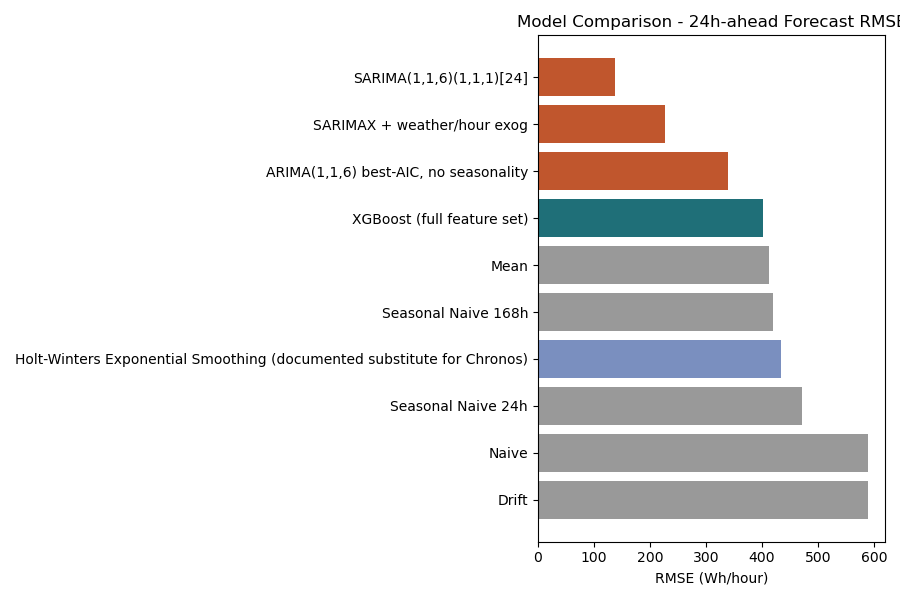

In [71]:
display(Image(f"{FIGDIR}/14_model_comparison.png"))

*Figure: RMSE comparison across every model in the study.*